# Multi Head Attention

Multihead attention means dividing the attention mechansim into multiple steps each operating independently

## Type 1 (Stacking multiple single head attention layers)

1. That is creating multiple instances of the self attention mechanism each with its own weights and then combining their outputs

2. This can be computationally intensive but it makes LLMs powerful at complex pattern recognition tasks

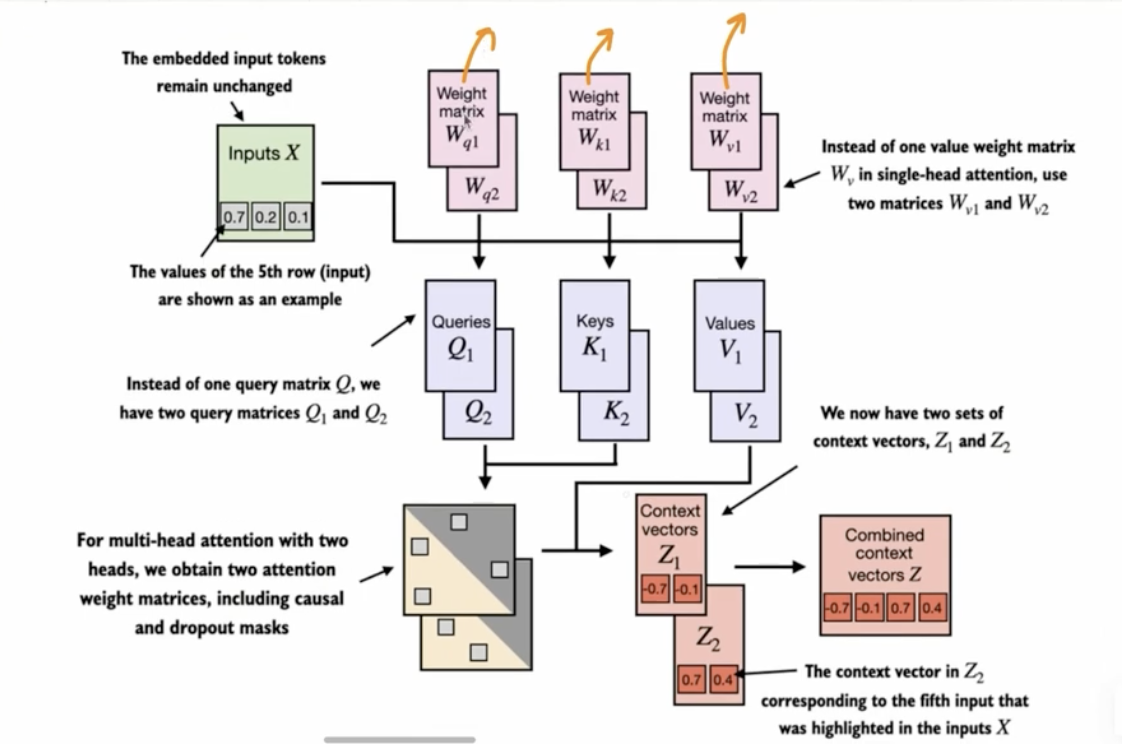

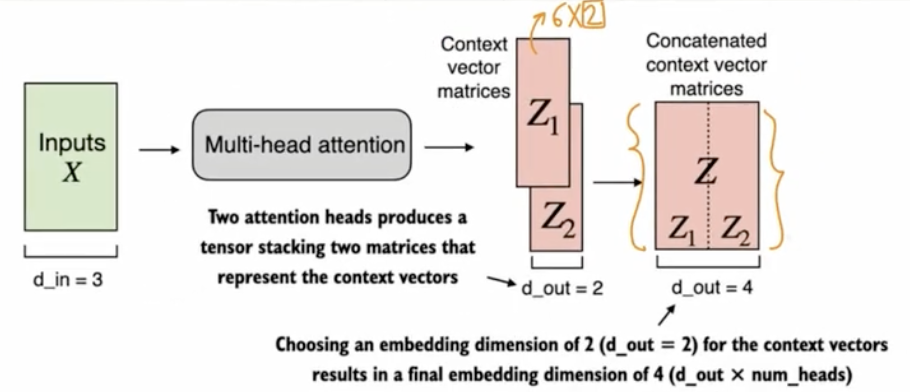

Run the attention mecahnsim multiple times (in parallel) with different, learned linear projections 

In [1]:
import torch
import torch.nn as nn

class CausalAttentionWithBatching(nn.Module):
    
    def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)

        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))
        
        
    def forward(self,x):
        batch_size, num_tokens, embedding_size = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        ## For every batch we need to independently transpose 
        attn_scores = queries @ keys.transpose(1,2)

        ## Inplace Masking
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens,:num_tokens],-torch.inf
        )
        ## :num_tokens is done to ensure that for cases 
        # where the number of tokens in the batch is smaller 
        # than the supported context_size

        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim =-1)

        ## drop out
        attn_weights= self.dropout(attn_weights)

        
        context_vec = attn_weights @ values
        return context_vec

## Extending multihead to single head attention (Sequential Execution)

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out, context_length,dropout,num_heads,qkv_bias = False):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                CausalAttentionWithBatching(d_in,d_out,context_length,dropout,qkv_bias)
                for i in range(num_heads)
            ]
        )


    def forward(self,x):
        return torch.cat([head(x) for head in self.heads],dim=-1)

In [9]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your      (x^1)
     [0.55, 0.87, 0.66],  # journey   (x^2)
     [0.57, 0.85, 0.64],  # starts    (x^3)
     [0.22, 0.58, 0.33],  # with      (x^4)
     [0.77, 0.25, 0.10],  # one       (x^5)
     [0.05, 0.80, 0.55]]  # step      (x^6)
)

inputs = torch.stack([inputs,inputs],dim=0)
print(inputs.shape)

torch.Size([2, 6, 3])


In [10]:
torch.manual_seed(123)
context_length = inputs.shape[1]
d_in = 3
d_out = 2

mha = MultiHeadAttention(d_in,d_out,context_length,0,num_heads=2)
mha.forward(inputs)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

Dimension - 2 * 6 * 4

2 - Batch size
6 - Context length
4 - Output size